I downloaded this .csv from Zillow, as I have been looking at houses and found it interesting.  I want to look at the correlation between home prices and crime rates.  I used chatgpt, Gemini, Google AI, and provided module references for guidance, troubleshooting and code examples, but the final revision and interpretations were reviewed and adapted by me.

These 2 code chunks were added after completion of module.  I had guidance from chatgpt:

This code connects my Google Drive to the Colab environment so the notebook can access files stored there.
drive.mount() creates a directory (/content/drive) that mirrors my Google Drive, allowing me to load datasets, save output files, and keep data persistent across Colab sessions. Without mounting Drive, files uploaded directly to Colab would be temporary and lost when the runtime resets.

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


"This code loads my cleaned, merged dataset (crime + home value data) directly from Google Drive into a pandas DataFrame. Using the Drive path ensures that the dataset is loaded consistently each time the notebook runs, making the analysis fully reproducible. The .head() call displays the first few rows to confirm the data loaded correctly."

In [41]:
import pandas as pd

path = '/content/drive/MyDrive/phoenix_crime_housing_2015_2017 (1).csv'

merged = pd.read_csv(path)
merged.head()

,ZIP,month,crime_count,zhvi,value_quartile
0,85003,2015-11,69,322335.681342,High
1,85003,2015-12,65,324289.155227,High
2,85003,2016-01,61,327547.904653,High
3,85003,2016-02,56,331011.290054,Very High
4,85003,2016-03,41,333443.717522,Very High


In [1]:
from google.colab import files
uploaded = files.upload()


Saving Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv to Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv


In [2]:
import pandas as pd

zhvi = pd.read_csv('Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')
zhvi.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,211260.036103,...,503615.315072,504041.821563,503718.362554,502808.007227,501009.557989,498808.457699,496204.055384,494124.281431,493001.330687,493204.183103
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,117013.178176,...,546231.311054,546796.399030,548762.235908,551106.382435,554471.978686,557358.140113,559986.738688,561842.069988,563135.564098,565788.741081
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,103949.915049,...,280364.214678,279752.347810,279127.333004,278293.728257,277333.261939,276527.656740,275525.866223,274583.243231,273646.325157,272866.097556
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,174013.827521,...,534715.303771,532223.576798,532092.170856,531746.686451,531633.596410,532026.401149,534097.682017,536855.532134,538527.597608,539769.173343
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,102741.047530,...,273881.498841,273638.371800,273235.446503,272375.802036,271334.625636,270440.150302,269437.236297,268523.691827,267647.045438,266768.667034


Separate date cols from other info cols:

In [3]:
import numpy as np

date_cols = [] #initialize empty lists
id_cols = []
for col in zhvi.columns: #loops through
    try:
        pd.to_datetime(col)  # convert name to date (works only for date-like column names ('2015-01-31'))
        date_cols.append(col)
    except Exception:
        id_cols.append(col) #puts the rest here

print("ID columns (first few):", id_cols[:10])  #prints summaries
print("Date columns (first few):", date_cols[:5], "… total:", len(date_cols))


ID columns (first few): ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName']
Date columns (first few): ['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31'] … total: 309


We need to "pivot_longer" in pandas, ie melt:  

In [4]:
zhvi_long = zhvi.melt(
    id_vars=id_cols,           # keep all non-date columns during melt
    value_vars=date_cols,      # stack all date columns
    var_name='date',
    value_name='zhvi'
)

Keep what we need for further analysis:

In [5]:
keep_cols = ['RegionName', 'StateName', 'date', 'zhvi']
zhvi_long = zhvi_long[keep_cols].copy()

Standardize ZIP and month:

In [6]:
zhvi_long['ZIP'] = zhvi_long['RegionName'].astype(str).str.zfill(5) #make sure ZIP is good
zhvi_long['month'] = pd.to_datetime(zhvi_long['date'], errors='coerce').dt.to_period('M') #make sure month is good

Keep only info from Arizona (filter):

In [7]:
zhvi_long = zhvi_long[zhvi_long['StateName'] == 'AZ']

Final column check:

The ZHVI in Zillow is the monthly estimate of typical home value for a ZIP code.  It is a smoothed, "median-like" calculation using the middle portion of the market (35-65th percentile).

In [8]:
zhvi_long = zhvi_long[['ZIP', 'month', 'zhvi']].sort_values(['ZIP', 'month'])
zhvi_long.head(10)

,ZIP,month,zhvi
10717,85003,2000-01,140453.631634
37027,85003,2000-02,141061.251067
63337,85003,2000-03,141910.157414
89647,85003,2000-04,143845.258656
115957,85003,2000-05,145868.175082
142267,85003,2000-06,147225.703337
168577,85003,2000-07,147914.301623
194887,85003,2000-08,148460.684066
221197,85003,2000-09,149552.060738
247507,85003,2000-10,150743.299075


In [9]:
zhvi_long.shape

(92700, 3)

I only need dates that correspond with my crime data, which runs from 11/2015 to 11/2017:

In [10]:
zhvi_long = zhvi_long[
    (zhvi_long['month'] >= '2015-11')
    & (zhvi_long['month'] <= '2017-11') #both must be true
].reset_index(drop=True) #reset row index, don't add old index as column
zhvi_long['month'].unique() #print to check

<PeriodArray>
['2015-11', '2015-12', '2016-01', '2016-02', '2016-03', '2016-04', '2016-05',
 '2016-06', '2016-07', '2016-08', '2016-09', '2016-10', '2016-11', '2016-12',
 '2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06', '2017-07',
 '2017-08', '2017-09', '2017-10', '2017-11']
Length: 25, dtype: period[M]

In [11]:
zhvi_long.head()

,ZIP,month,zhvi
0,85003,2015-11,322335.681342
1,85003,2015-12,324289.155227
2,85003,2016-01,327547.904653
3,85003,2016-02,331011.290054
4,85003,2016-03,333443.717522


In [12]:
zhvi_long.shape

(7500, 3)

Now I'm ready to upload cleaned dataset from Module 3 Basics:

In [13]:
from google.colab import files
uploaded = files.upload()

Saving crime_clean.csv to crime_clean.csv


In [15]:
# Load the crime data from the file into df
crime_df = pd.read_csv('crime_clean.csv')

In [17]:
crime_month_zip = (
    df.groupby(['ZIP', 'month'])
      .size()
      .reset_index(name='crime_count')
)


In [18]:
crime_month_zip.head()

,ZIP,month,crime_count
0,85003,2015-11,69
1,85003,2015-12,65
2,85003,2016-01,61
3,85003,2016-02,56
4,85003,2016-03,41


In [21]:
crime_month_zip.shape

(1500, 3)

Looks good.  I'll merge the crime and housing data.  Code provided and explained line by line by chatgpt:

In [23]:
# Convert 'ZIP' column to string in both dataframes/mutate as.character in R
crime_month_zip['ZIP'] = crime_month_zip['ZIP'].astype(str)
zhvi_long['ZIP'] = zhvi_long['ZIP'].astype(str)

# Convert 'month' column to period[M] in crime_month_zip/using lubridate in R
crime_month_zip['month'] = pd.to_datetime(crime_month_zip['month']).dt.to_period('M')

merged = crime_month_zip.merge(  #this is a left_join in R
    zhvi_long,
    on=['ZIP', 'month'],
    how='left'
)

In [24]:
merged.head()

,ZIP,month,crime_count,zhvi
0,85003,2015-11,69,322335.681342
1,85003,2015-12,65,324289.155227
2,85003,2016-01,61,327547.904653
3,85003,2016-02,56,331011.290054
4,85003,2016-03,41,333443.717522


In [25]:
merged.shape

(1500, 4)

In [26]:
merged.info()
merged[['crime_count','zhvi']].describe()
merged.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype    
---  ------       --------------  -----    
 0   ZIP          1500 non-null   object   
 1   month        1500 non-null   period[M]
 2   crime_count  1500 non-null   int64    
 3   zhvi         1499 non-null   float64  
dtypes: float64(1), int64(1), object(1), period[M](1)
memory usage: 47.0+ KB


,0
ZIP,0
month,0
crime_count,0
zhvi,1


Need to get rid of 1 missing value in zhvi

In [27]:
merged[merged['zhvi'].isna()]

,ZIP,month,crime_count,zhvi
1221,85290,2016-07,1,NaN


In [28]:
merged = merged.dropna(subset=['zhvi']).reset_index(drop=True)


In [29]:
merged.isna().sum()
merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype    
---  ------       --------------  -----    
 0   ZIP          1499 non-null   object   
 1   month        1499 non-null   period[M]
 2   crime_count  1499 non-null   int64    
 3   zhvi         1499 non-null   float64  
dtypes: float64(1), int64(1), object(1), period[M](1)
memory usage: 47.0+ KB


Scatterplot (crime vs home value)

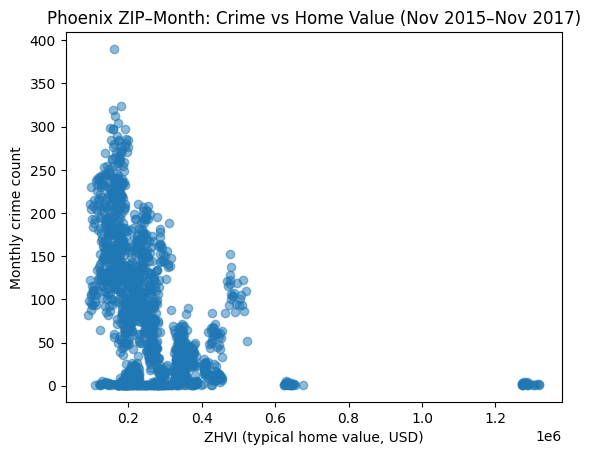

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(merged['zhvi'], merged['crime_count'], alpha=0.5)
plt.xlabel('ZHVI (typical home value, USD)') #typical defined earlier
plt.ylabel('Monthly crime count')
plt.title('Phoenix ZIP–Month: Crime vs Home Value (Nov 2015–Nov 2017)')
plt.show()


That is an ugly graph.  I miss ggplot2.  I asked chatgpt for a ggplot=style graph with a corrected y axis.  

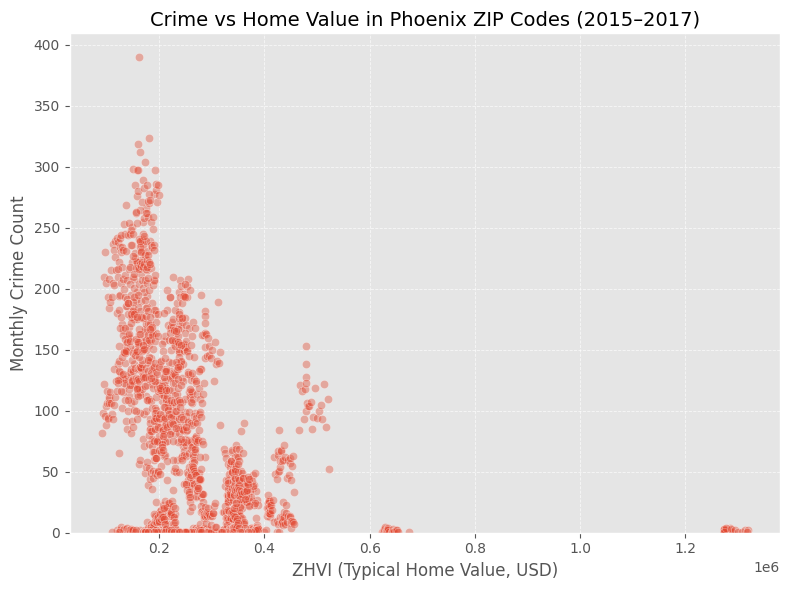

In [30]:
plt.style.use('ggplot')  # ✅ gives a clean ggplot2-like look

plt.figure(figsize=(8,6))  # ✅ larger figure for better readability

plt.scatter(
    merged['zhvi'],
    merged['crime_count'],
    alpha=0.4,
    edgecolor='white',
    linewidth=0.5
)

# ✅ Clean labels
plt.xlabel('ZHVI (Typical Home Value, USD)', fontsize=12)
plt.ylabel('Monthly Crime Count', fontsize=12)
plt.title('Crime vs Home Value in Phoenix ZIP Codes (2015–2017)', fontsize=14)

# ✅ Force y-axis to start at zero
plt.ylim(bottom=0)

# ✅ Cleaner grid
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()


Chat gpt recommended Seaborn. I asked for a regression line.  

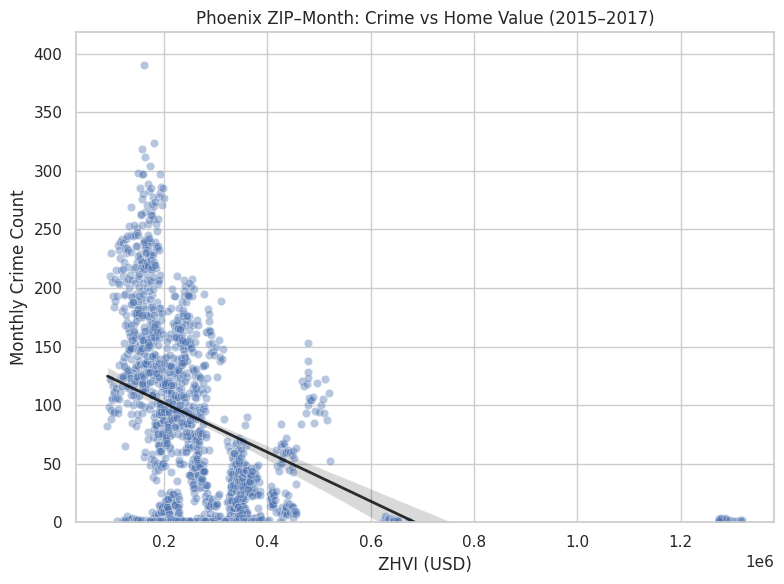

In [35]:
import seaborn as sns

sns.set_theme(style="whitegrid")  # similar to ggplot2

plt.figure(figsize=(8,6))

# ✅ Regression line (drawn first so it sits under the scatter points)
sns.regplot(
    data=merged,
    x='zhvi',
    y='crime_count',
    scatter=False,     # turn off built-in scatter, we already draw it below
    color='black',     # clean, contrasts well
    line_kws={'linewidth': 2, 'alpha': 0.8}
)

# ✅ Scatter plot on top
sns.scatterplot(
    data=merged,
    x='zhvi',
    y='crime_count',
    alpha=0.4,
    edgecolor='white'
)

plt.ylim(0, None)
plt.xlabel('ZHVI (USD)')
plt.ylabel('Monthly Crime Count')
plt.title('Phoenix ZIP–Month: Crime vs Home Value (2015–2017)')
plt.tight_layout()
plt.show()



This chart shows the 15 Phoenix ZIP codes with the highest average monthly crime counts over the November 2015–November 2017 period. Each bar represents the average number of crimes reported per month in that ZIP code, allowing us to quickly identify areas with consistently higher crime levels.  Chatgpt provided code after input from me.  If I was reporting this information to a third party I would do more data investigation.

Here is a short summary provided by chatgpt of the home value and crime relationship:  A simple linear regression of monthly crime counts on ZHVI (typical home value) shows a statistically significant negative relationship between home values and crime. The coefficient for ZHVI is small but highly significant (p < 0.001), indicating that crime tends to be slightly lower in ZIP codes with higher home values. However, the model explains only about 18% of the variance in crime counts (R² = 0.185), suggesting that home values alone are a weak predictor and that most variation in crime is driven by other factors.

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(merged['zhvi'])   # intercept + zhvi
y = merged['crime_count']
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            crime_count   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     339.8
Date:                Thu, 30 Oct 2025   Prob (F-statistic):           1.52e-68
Time:                        22:00:57   Log-Likelihood:                -8484.9
No. Observations:                1499   AIC:                         1.697e+04
Df Residuals:                    1497   BIC:                         1.698e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        143.8268      3.539     40.646      0.0

Bar chart of average monthly crime by home value quartile. I decided to view the data by quartiles for easier interpretation.  I asked chatgpt for assistance in code and write up:  

This chart compares average monthly crime across home-value quartiles, allowing us to see how crime levels differ between lower-value and higher-value ZIP codes. By aggregating the data into quartiles, the relationship between home prices and crime becomes clearer and easier to interpret than looking at individual ZIPs.

/tmp/ipython-input-2198505016.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby('value_quartile')['crime_count']
/tmp/ipython-input-2198505016.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


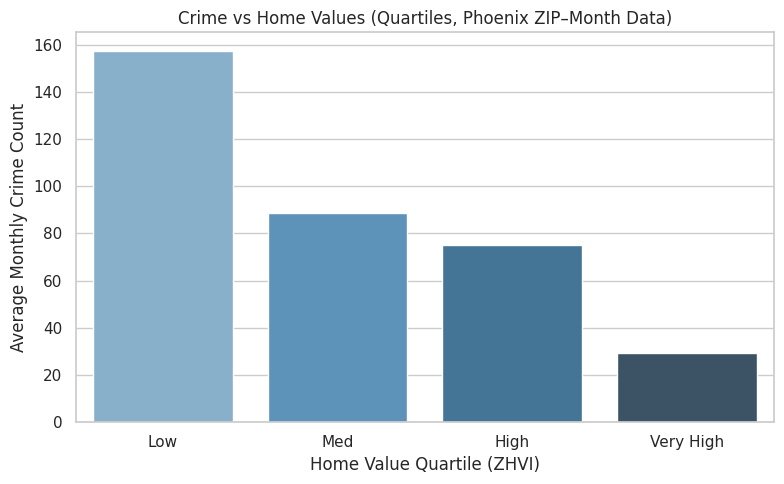

In [37]:
# Create quartiles based on ZHVI
merged['value_quartile'] = pd.qcut(merged['zhvi'], 4, labels=['Low', 'Med', 'High', 'Very High'])

quartile_crime = (
    merged.groupby('value_quartile')['crime_count']
          .mean()
          .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=quartile_crime,
    x='value_quartile',
    y='crime_count',
    palette='Blues_d'
)

plt.xlabel('Home Value Quartile (ZHVI)')
plt.ylabel('Average Monthly Crime Count')
plt.title('Crime vs Home Values (Quartiles, Phoenix ZIP–Month Data)')
plt.tight_layout()
plt.show()


Copy of my merged dataset to .csv, converts month to simple string, and exports final dataset to .csv file.    

In [38]:
merged_out = merged.copy()
# make month a string for CSV readability
merged_out['month'] = merged_out['month'].astype(str)
merged_out.to_csv('phoenix_crime_housing_2015_2017.csv', index=False)


In [39]:
from google.colab import files
files.download('phoenix_crime_housing_2015_2017.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>